## Multirun Stability Analysis (Latest `train_multirun.sbatch`)
This notebook follows the newest `clariden/train_multirun.sbatch` search space and compares it to restored baseline runs from `layers.ipynb`.
- multirun model: `apertus`
- layers: `10, 20, 26, 30`
- seeds: `42, 43, 44`
- learning rates: `1e-3, 3e-4, 1e-4, 3e-5`
- variants: `ln_fp32`, `fp32_only`, `ln_bf16`, `bf16_only`
- baselines: `apertus_no_lora_long_form_layer{layer}_seed{seed}` and `llama_no_lora_long_form_layer{layer}_seed{seed}` (`lr=1e-3`)

In [29]:
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import wandb

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

api = wandb.Api()
ENTITY = "ethz-lsai-25"
PROJECT = "hallucination-probes"
RUN_PATH = f"{ENTITY}/{PROJECT}"

In [30]:
MODEL = "apertus"
LAYERS = [10, 20, 26, 30]
SEEDS = [42, 43, 44]
LRS = ["1e-3", "3e-4", "1e-4", "3e-5"]
TEST_MODELS = ["apertus", "llama"]
METRIC_FAMILIES = ["all", "span", "span_max"]
METRICS = ["auc", "f1", "acc", "recall_at_0.1_fpr"]
VARIANTS = ["ln_fp32", "fp32_only", "ln_bf16", "bf16_only"]
BASELINE_VARIANTS = ["apertus_layers", "llama_layers"]
ALL_VARIANTS = BASELINE_VARIANTS + VARIANTS

VARIANT_META = {
    "apertus_layers": {"normalize_before_head": "none", "probe_dtype": "bfloat16", "train_model": "apertus"},
    "llama_layers": {"normalize_before_head": "none", "probe_dtype": "bfloat16", "train_model": "llama"},
    "ln_fp32": {"normalize_before_head": "layernorm", "probe_dtype": "float32", "train_model": "apertus"},
    "fp32_only": {"normalize_before_head": "none", "probe_dtype": "float32", "train_model": "apertus"},
    "ln_bf16": {"normalize_before_head": "layernorm", "probe_dtype": "bfloat16", "train_model": "apertus"},
    "bf16_only": {"normalize_before_head": "none", "probe_dtype": "bfloat16", "train_model": "apertus"},
}

LR_TAG_TO_VALUE = {"1em3": "1e-3", "3em4": "3e-4", "1em4": "1e-4", "3em5": "3e-5"}
RUN_NAME_PATTERN = re.compile(
    r"^apertus_no_lora_(ln_fp32|fp32_only|ln_bf16|bf16_only)_layer(10|20|26|30)_seed(42|43|44)_lr(1em3|3em4|1em4|3em5)$"
)
BASELINE_PATTERN = re.compile(
    r"^(apertus|llama)_no_lora_long_form_layer(10|20|26|30)_seed(42|43|44)$"
)


def _extract_probe_id(run):
    name = run.name or ""
    if RUN_NAME_PATTERN.match(name) or BASELINE_PATTERN.match(name):
        return name
    cfg = run.config or {}
    if isinstance(cfg.get("probe_config"), dict):
        nested = cfg["probe_config"].get("probe_id")
        if isinstance(nested, str) and (RUN_NAME_PATTERN.match(nested) or BASELINE_PATTERN.match(nested)):
            return nested
    for k in ["probe_config.probe_id", "probe_config/probe_id", "probe_id"]:
        v = cfg.get(k)
        if isinstance(v, str) and (RUN_NAME_PATTERN.match(v) or BASELINE_PATTERN.match(v)):
            return v
    return None


def _safe_float(x):
    try:
        return float(x)
    except (TypeError, ValueError):
        return None

In [31]:
rows = []
for run in api.runs(RUN_PATH):
    probe_id = _extract_probe_id(run)
    if not probe_id:
        continue

    m = RUN_NAME_PATTERN.match(probe_id)
    if m:
        variant, layer, seed, lr_tag = m.groups()
        lr = LR_TAG_TO_VALUE[lr_tag]
    else:
        b = BASELINE_PATTERN.match(probe_id)
        if not b:
            continue
        baseline_model, layer, seed = b.groups()
        variant = f"{baseline_model}_layers"
        lr = None

    summary = run.summary._json_dict
    row = {
        "run_id": run.id,
        "run_name": run.name,
        "probe_id": probe_id,
        "state": run.state,
        "created_at": pd.to_datetime(run.created_at, utc=True),
        "train_model": VARIANT_META[variant]["train_model"],
        "variant": variant,
        "layer": int(layer),
        "seed": int(seed),
        "lr": lr,
        "normalize_before_head": VARIANT_META[variant]["normalize_before_head"],
        "probe_dtype": VARIANT_META[variant]["probe_dtype"],
    }
    for test_model in TEST_MODELS:
        for family in METRIC_FAMILIES:
            for metric in METRICS:
                key = f"train/longfact_test_{test_model}/{family}_{metric}"
                row[key] = _safe_float(summary.get(key))
    rows.append(row)

df_runs = pd.DataFrame(rows)
if df_runs.empty:
    raise ValueError("No runs matched multirun or baseline naming patterns.")

state_rank = {"finished": 0, "running": 1, "queued": 2, "failed": 3, "crashed": 4}
df_runs["_state_rank"] = df_runs["state"].map(state_rank).fillna(99)
df_runs = (
    df_runs.sort_values(["_state_rank", "created_at"], ascending=[True, False])
    .drop_duplicates(["variant", "layer", "seed", "lr"], keep="first")
    .drop(columns=["_state_rank"])
    .sort_values(["variant", "layer", "seed", "lr"])
    .reset_index(drop=True)
)

expected = len(VARIANTS) * len(LAYERS) * len(SEEDS) * len(LRS)
print(f"Expected multirun combinations: {expected}")
print(f"Available total rows (including baselines): {len(df_runs)}")
print("Baseline note: layers.ipynb-style Apertus/Llama runs are treated as fixed-lr baselines (lr=1e-3).")
display(df_runs.groupby(["variant", "layer"]).size().rename("n").reset_index())
df_runs.head()

Expected multirun combinations: 192
Available total rows (including baselines): 216
Baseline note: layers.ipynb-style Apertus/Llama runs are treated as fixed-lr baselines (lr=1e-3).


,variant,layer,n
0,apertus_layers,10,3
1,apertus_layers,20,3
2,apertus_layers,26,3
3,apertus_layers,30,3
4,bf16_only,10,12
5,bf16_only,20,12
6,bf16_only,26,12
7,bf16_only,30,12
8,fp32_only,10,12
9,fp32_only,20,12


,run_id,run_name,probe_id,state,created_at,train_model,variant,layer,seed,lr,...,train/longfact_test_llama/all_acc,train/longfact_test_llama/all_recall_at_0.1_fpr,train/longfact_test_llama/span_auc,train/longfact_test_llama/span_f1,train/longfact_test_llama/span_acc,train/longfact_test_llama/span_recall_at_0.1_fpr,train/longfact_test_llama/span_max_auc,train/longfact_test_llama/span_max_f1,train/longfact_test_llama/span_max_acc,train/longfact_test_llama/span_max_recall_at_0.1_fpr
0,2msk68xv,apertus_no_lora_long_form_layer10_seed42,apertus_no_lora_long_form_layer10_seed42,finished,2026-03-02 14:54:28+00:00,apertus,apertus_layers,10,42,None,...,None,0.515747,0.813953,0.493873,None,0.503486,0.857475,0.639567,None,0.596943
1,ennpfi5c,apertus_no_lora_long_form_layer10_seed43,apertus_no_lora_long_form_layer10_seed43,finished,2026-03-02 14:55:28+00:00,apertus,apertus_layers,10,43,None,...,None,0.518234,0.818641,0.545862,None,0.511309,0.857727,0.650889,None,0.601263
2,ckfvtpqq,apertus_no_lora_long_form_layer10_seed44,apertus_no_lora_long_form_layer10_seed44,finished,2026-03-02 14:55:28+00:00,apertus,apertus_layers,10,44,None,...,None,0.502054,0.817217,0.573266,None,0.513465,0.858686,0.658098,None,0.605084
3,5w54hojz,apertus_no_lora_long_form_layer20_seed42,apertus_no_lora_long_form_layer20_seed42,finished,2026-03-02 14:56:24+00:00,apertus,apertus_layers,20,42,None,...,None,0.379366,0.753350,0.410840,None,0.411978,0.838865,0.643215,None,0.565875
4,h3qhm4bp,apertus_no_lora_long_form_layer20_seed43,apertus_no_lora_long_form_layer20_seed43,finished,2026-03-02 14:56:24+00:00,apertus,apertus_layers,20,43,None,...,None,0.400283,0.762320,0.424261,None,0.422082,0.841573,0.640421,None,0.573185


In [46]:
metric_columns = [
    f"train/longfact_test_{tm}/{fam}_{m}"
    for tm in TEST_MODELS
    for fam in METRIC_FAMILIES
    for m in METRICS
]

df_long = df_runs.melt(
    id_vars=[
        "run_id", "run_name", "probe_id", "state", "created_at", "train_model",
        "variant", "layer", "seed", "lr", "normalize_before_head", "probe_dtype"
    ],
    value_vars=metric_columns,
    var_name="metric_key",
    value_name="value",
)

parts = df_long["metric_key"].str.extract(
    r"train/longfact_test_(apertus|llama)/(all|span|span_max)_(auc|f1|acc|recall_at_0\.1_fpr)"
)

parts.columns = ["test_model", "metric_family", "metric"]
df_long = pd.concat([df_long, parts], axis=1)
df_long = df_long.dropna(subset=["value", "test_model", "metric_family", "metric"])
df_long["value"] = pd.to_numeric(df_long["value"], errors="coerce")
df_long = df_long.dropna(subset=["value"]).reset_index(drop=True)
df_long["lr"] = pd.Categorical(df_long["lr"], categories=LRS, ordered=True)
df_long["variant"] = pd.Categorical(df_long["variant"], categories=ALL_VARIANTS, ordered=True)
df_long.head()

,run_id,run_name,probe_id,state,created_at,train_model,variant,layer,seed,lr,normalize_before_head,probe_dtype,metric_key,value,test_model,metric_family,metric
0,2msk68xv,apertus_no_lora_long_form_layer10_seed42,apertus_no_lora_long_form_layer10_seed42,finished,2026-03-02 14:54:28+00:00,apertus,apertus_layers,10,42,NaN,none,bfloat16,train/longfact_test_apertus/all_auc,0.834979,apertus,all,auc
1,ennpfi5c,apertus_no_lora_long_form_layer10_seed43,apertus_no_lora_long_form_layer10_seed43,finished,2026-03-02 14:55:28+00:00,apertus,apertus_layers,10,43,NaN,none,bfloat16,train/longfact_test_apertus/all_auc,0.830068,apertus,all,auc
2,ckfvtpqq,apertus_no_lora_long_form_layer10_seed44,apertus_no_lora_long_form_layer10_seed44,finished,2026-03-02 14:55:28+00:00,apertus,apertus_layers,10,44,NaN,none,bfloat16,train/longfact_test_apertus/all_auc,0.823364,apertus,all,auc
3,5w54hojz,apertus_no_lora_long_form_layer20_seed42,apertus_no_lora_long_form_layer20_seed42,finished,2026-03-02 14:56:24+00:00,apertus,apertus_layers,20,42,NaN,none,bfloat16,train/longfact_test_apertus/all_auc,0.721613,apertus,all,auc
4,h3qhm4bp,apertus_no_lora_long_form_layer20_seed43,apertus_no_lora_long_form_layer20_seed43,finished,2026-03-02 14:56:24+00:00,apertus,apertus_layers,20,43,NaN,none,bfloat16,train/longfact_test_apertus/all_auc,0.732504,apertus,all,auc


/tmp/ipykernel_4143/1717218393.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  main.groupby(["variant", "layer", "lr"])
/tmp/ipykernel_4143/1717218393.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  baselines.groupby(["variant", "layer"])
/tmp/ipykernel_4143/1717218393.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  main.groupby(["variant", "layer", "lr"])
/tmp/ipykernel_4143/1717218393.py:70: FutureWarnin

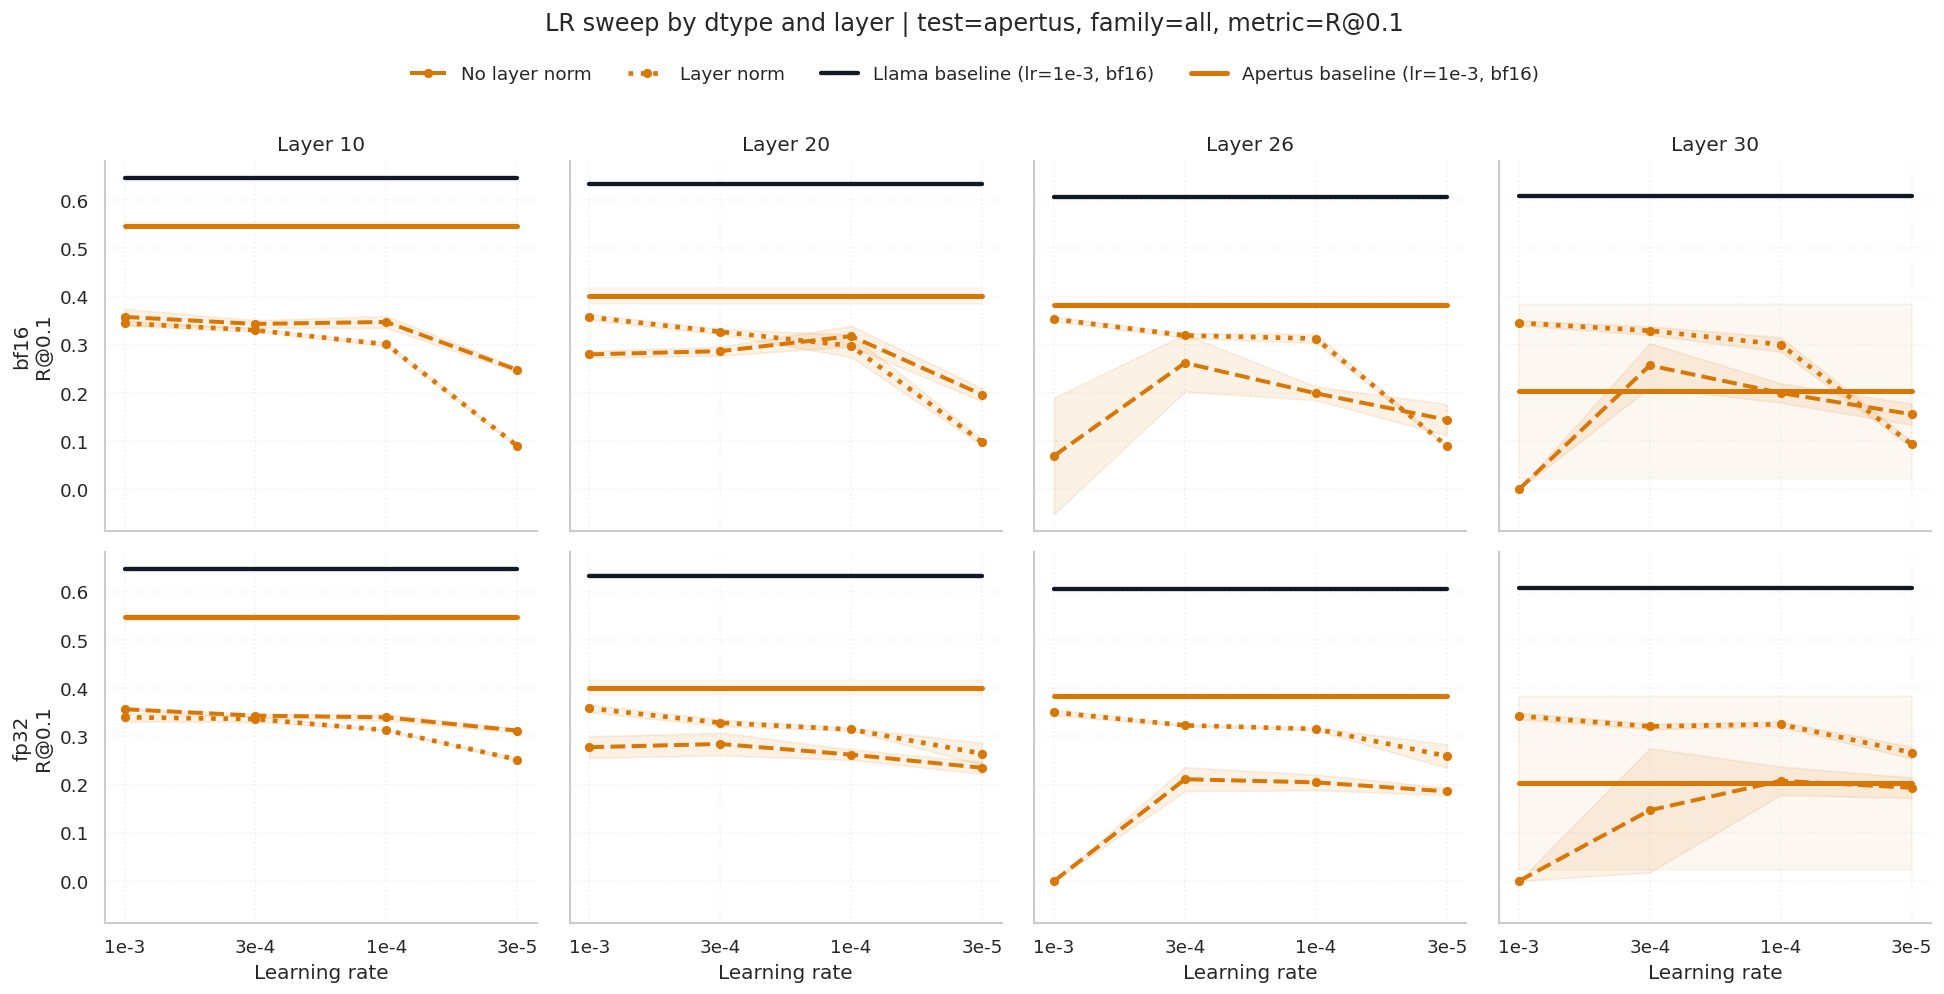

In [38]:
APERTUS_COLOR = "#D97706"
LLAMA_COLOR = "#111827"
STYLE_MAP = {
    "apertus_layers": {"label": "Apertus baseline (lr=1e-3, bf16)", "color": APERTUS_COLOR, "linestyle": "-", "linewidth": 3.0, "zorder": 5},
    "llama_layers": {"label": "Llama baseline (lr=1e-3, bf16)", "color": LLAMA_COLOR, "linestyle": "-", "linewidth": 2.6, "zorder": 4},
    "bf16_only": {"label": "No layer norm", "color": APERTUS_COLOR, "linestyle": "--", "linewidth": 2.4, "zorder": 3},
    "ln_bf16": {"label": "Layer norm", "color": APERTUS_COLOR, "linestyle": ":", "linewidth": 2.8, "zorder": 3},
    "fp32_only": {"label": "No layer norm", "color": APERTUS_COLOR, "linestyle": "--", "linewidth": 2.4, "zorder": 3},
    "ln_fp32": {"label": "Layer norm", "color": APERTUS_COLOR, "linestyle": ":", "linewidth": 2.8, "zorder": 3},
}
DTYPE_GROUPS = [
    ("bf16", ["bf16_only", "ln_bf16"]),
    ("fp32", ["fp32_only", "ln_fp32"]),
]
METRIC_LABELS = {
    "auc": "AUC",
    "f1": "F1",
    "acc": "Accuracy",
    "recall_at_0.1_fpr": "R@0.1",
}


def _plot_baseline(ax, base_agg, variant, xpos):
    style = STYLE_MAP[variant]
    s = base_agg[base_agg["variant"] == variant]
    if s.empty:
        return
    y0 = float(s["mean"].iloc[0])
    e0 = float(s["std"].iloc[0])
    ax.plot(
        xpos, [y0] * len(LRS), color=style["color"], linestyle=style["linestyle"],
        linewidth=style["linewidth"], label=variant, zorder=style["zorder"]
    )
    ax.fill_between(
        xpos, [y0 - e0] * len(LRS), [y0 + e0] * len(LRS), color=style["color"],
        alpha=0.06 if variant == "apertus_layers" else 0.05, zorder=0
    )


def plot_lr_two_panel(df, metric_family="all", metric="f1", test_model="llama"):
    sub = df[
        (df["metric_family"] == metric_family)
        & (df["metric"] == metric)
        & (df["test_model"] == test_model)
    ].copy()
    if sub.empty:
        raise ValueError("No rows for selected filters.")

    metric_label = METRIC_LABELS.get(metric, metric)

    xpos = list(range(len(LRS)))
    fig, axes = plt.subplots(len(DTYPE_GROUPS), len(LAYERS), figsize=(4.1 * len(LAYERS), 3.9 * len(DTYPE_GROUPS)), sharex=True, sharey=True)
    if len(DTYPE_GROUPS) == 1:
        axes = [axes]
    if len(LAYERS) == 1:
        axes = [[ax] for ax in axes]

    for row_idx, (dtype_label, variants) in enumerate(DTYPE_GROUPS):
        main = sub[sub["variant"].isin(variants)]
        baselines = sub[sub["variant"].isin(BASELINE_VARIANTS)]

        main_agg = (
            main.groupby(["variant", "layer", "lr"])
            .agg(mean=("value", "mean"), std=("value", "std"))
            .reset_index()
        )
        main_agg["std"] = main_agg["std"].fillna(0.0)

        base_agg = (
            baselines.groupby(["variant", "layer"])
            .agg(mean=("value", "mean"), std=("value", "std"))
            .reset_index()
        )
        base_agg["std"] = base_agg["std"].fillna(0.0)

        for col_idx, layer in enumerate(LAYERS):
            ax = axes[row_idx][col_idx]
            d_main = main_agg[main_agg["layer"] == layer]
            d_base = base_agg[base_agg["layer"] == layer]

            for variant in variants:
                style = STYLE_MAP[variant]
                s = d_main[d_main["variant"] == variant].set_index("lr").reindex(LRS).reset_index()
                y = s["mean"].to_numpy()
                e = s["std"].to_numpy()
                if pd.isna(y).all():
                    continue
                ax.plot(
                    xpos, y, color=style["color"], linestyle=style["linestyle"], linewidth=style["linewidth"],
                    marker="o", markersize=4.5, label=variant, zorder=style["zorder"]
                )
                ax.fill_between(xpos, y - e, y + e, color=style["color"], alpha=0.10, zorder=1)

            _plot_baseline(ax, d_base, "llama_layers", xpos)
            _plot_baseline(ax, d_base, "apertus_layers", xpos)

            if row_idx == 0:
                ax.set_title(f"Layer {layer}")
            if col_idx == 0:
                ax.set_ylabel(f"{dtype_label}\n{metric_label}")
            if row_idx == len(DTYPE_GROUPS) - 1:
                ax.set_xlabel("Learning rate")
            ax.set_xticks(xpos)
            ax.set_xticklabels(LRS)
            ax.grid(True, alpha=0.25, linestyle=":")
            ax.spines[["top", "right"]].set_visible(False)

    handles, labels = axes[0][0].get_legend_handles_labels()
    seen = set()
    uniq = [(h, l) for h, l in zip(handles, labels) if not (l in seen or seen.add(l))]
    handles = [h for h, _ in uniq]
    labels = [STYLE_MAP[l]["label"] for _, l in uniq]
    fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(f"LR sweep by dtype and layer | test={test_model}, family={metric_family}, metric={metric_label}", y=1.06)
    fig.tight_layout()
    plt.show()


plot_lr_two_panel(df_long, metric_family="all", metric="recall_at_0.1_fpr", test_model="apertus")

/tmp/ipykernel_4143/1717218393.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  main.groupby(["variant", "layer", "lr"])
/tmp/ipykernel_4143/1717218393.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  baselines.groupby(["variant", "layer"])
/tmp/ipykernel_4143/1717218393.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  main.groupby(["variant", "layer", "lr"])
/tmp/ipykernel_4143/1717218393.py:70: FutureWarnin

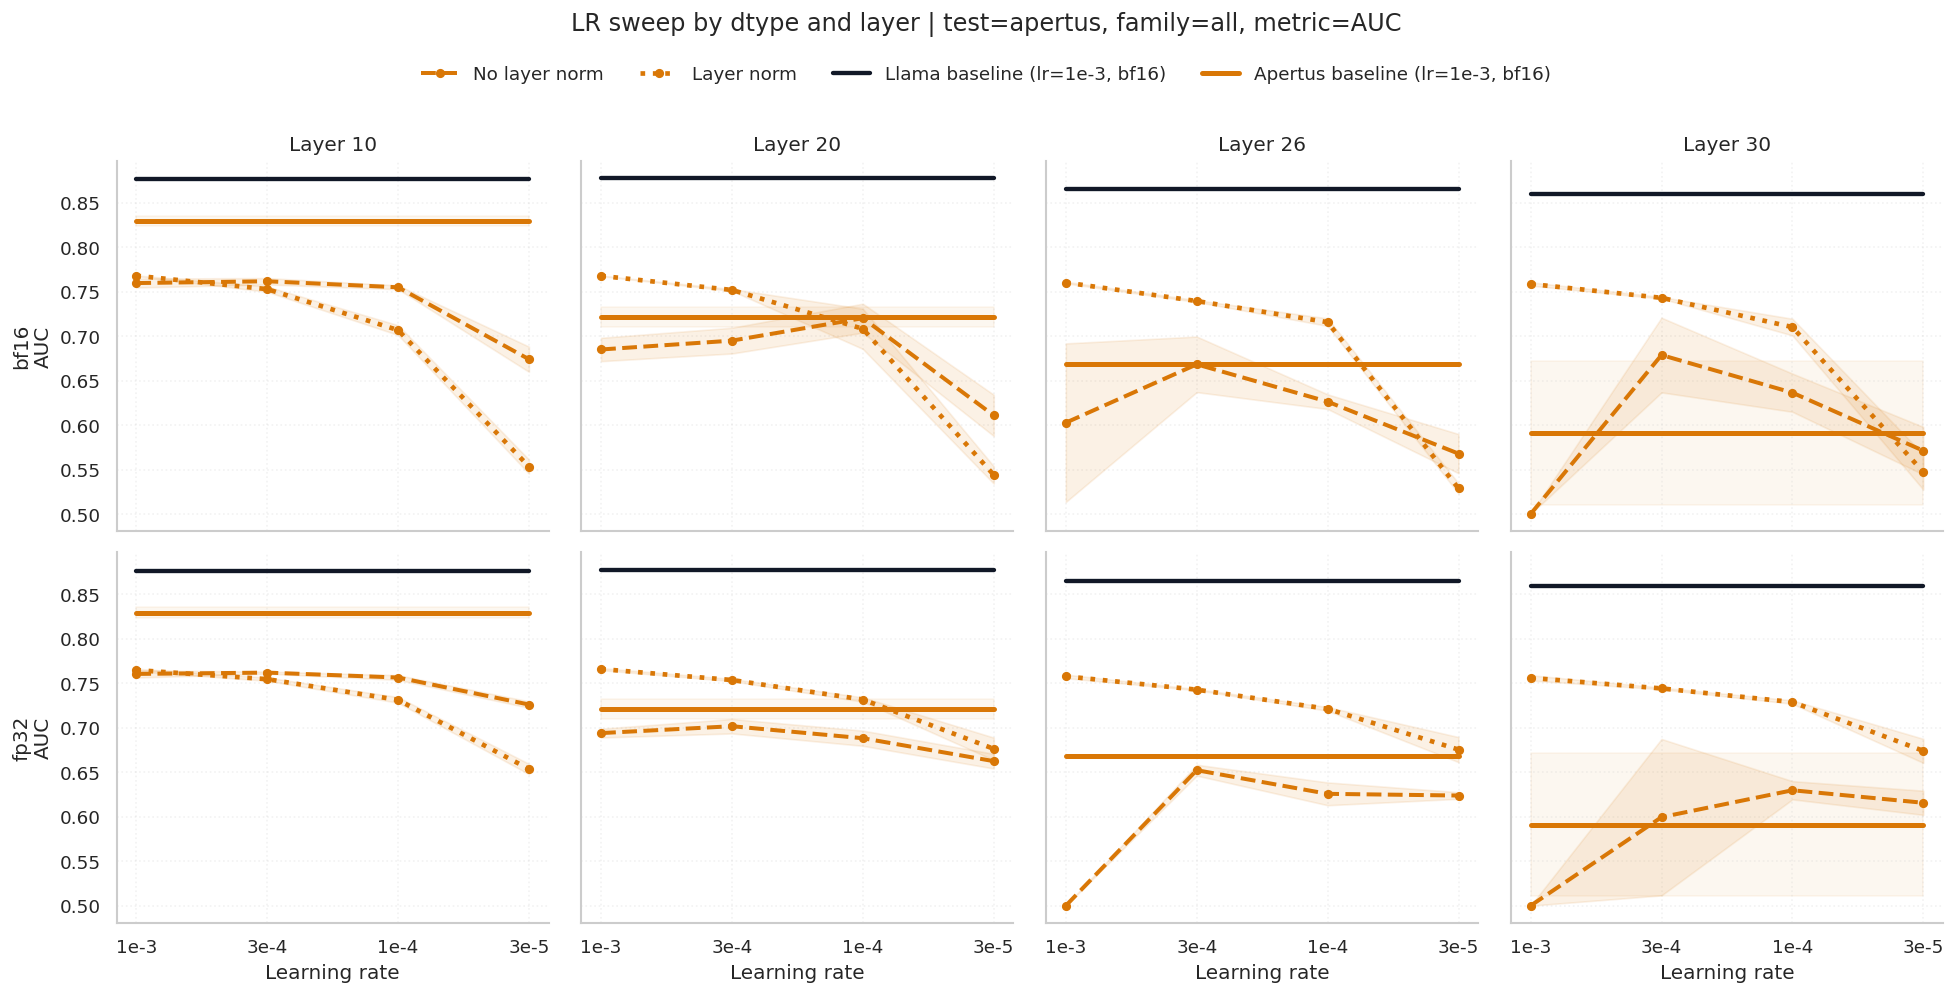

/tmp/ipykernel_4143/1717218393.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  main.groupby(["variant", "layer", "lr"])
/tmp/ipykernel_4143/1717218393.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  baselines.groupby(["variant", "layer"])
/tmp/ipykernel_4143/1717218393.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  main.groupby(["variant", "layer", "lr"])
/tmp/ipykernel_4143/1717218393.py:70: FutureWarnin

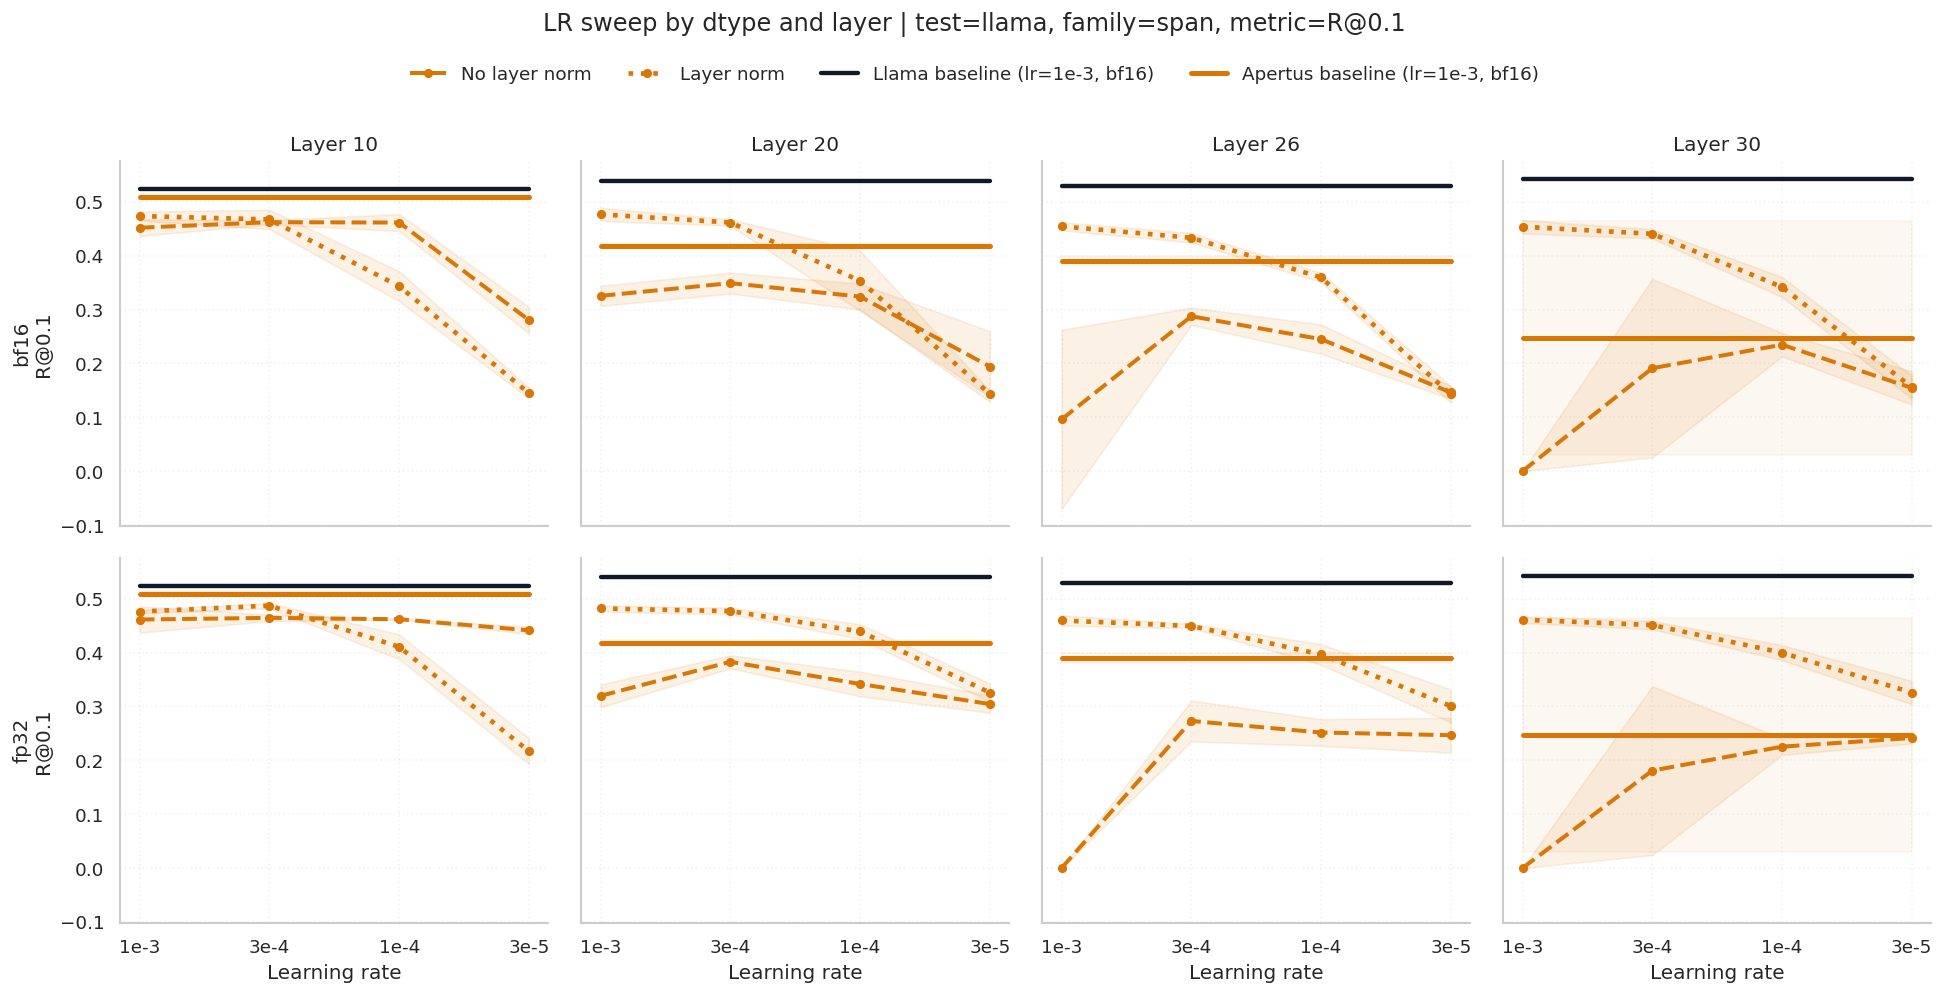

In [39]:
# Optional views
plot_lr_two_panel(df_long, metric_family="all", metric="auc", test_model="apertus")
plot_lr_two_panel(df_long, metric_family="span", metric="recall_at_0.1_fpr", test_model="llama")

In [72]:
# W&B config export + diff helper (ID-based only)
from collections.abc import Mapping
from pathlib import Path
import json
import pandas as pd

def _flatten_dict(obj, parent_key="", sep="."):
    items = {}
    if isinstance(obj, Mapping):
        for k, v in obj.items():
            new_key = f"{parent_key}{sep}{k}" if parent_key else str(k)
            if isinstance(v, Mapping):
                items.update(_flatten_dict(v, new_key, sep=sep))
            elif isinstance(v, list):
                for i, elem in enumerate(v):
                    list_key = f"{new_key}[{i}]"
                    if isinstance(elem, Mapping):
                        items.update(_flatten_dict(elem, list_key, sep=sep))
                    else:
                        items[list_key] = elem
            else:
                items[new_key] = v
    else:
        items[parent_key or "value"] = obj
    return items

def _fetch_run_by_id(run_id, entity=ENTITY, project=PROJECT):
    return api.run(f"{entity}/{project}/{run_id}")

def _safe_summary_value(summary, key):
    v = summary.get(key)
    try:
        if v is None:
            return None
        return float(v)
    except (TypeError, ValueError):
        return v

def run_overview_by_ids(baseline_run_id, ablation_run_id, entity=ENTITY, project=PROJECT):
    metric_keys = [
        "train/longfact_test_apertus/all_auc",
        "train/longfact_test_apertus/all_f1",
        "train/longfact_test_apertus/all_recall_at_0.1_fpr",
        "train/longfact_test_llama/all_auc",
        "train/longfact_test_llama/all_f1",
        "train/longfact_test_llama/all_recall_at_0.1_fpr",
    ]

    rows = []
    for run_id in [baseline_run_id, ablation_run_id]:
        run = _fetch_run_by_id(run_id, entity=entity, project=project)
        cfg_flat = _flatten_dict(run.config or {})
        summary = run.summary._json_dict if run.summary is not None else {}
        row = {
            "run_id": run.id,
            "name": run.name,
            "state": run.state,
            "created_at": run.created_at,
            "heartbeat_at": getattr(run, "heartbeatAt", None),
            "group": run.group,
            "job_type": run.job_type,
            "sweep_id": run.sweep.id if getattr(run, "sweep", None) is not None else None,
            "host": run.host,
            "tags": ", ".join(run.tags or []),
            "url": run.url,
            "config_keys": len(cfg_flat),
            "summary_keys": len(summary),
            "model_dtype": cfg_flat.get("model_dtype"),
            "probe_dtype": cfg_flat.get("probe_config.probe_dtype"),
            "normalize_before_head": cfg_flat.get("probe_config.normalize_before_head"),
            "probe_head_lr": cfg_flat.get("probe_head_lr"),
            "lambda_kl": cfg_flat.get("lambda_kl"),
            "lambda_lm": cfg_flat.get("lambda_lm"),
        }
        for key in metric_keys:
            row[key] = _safe_summary_value(summary, key)
        rows.append(row)

    overview = pd.DataFrame(rows)
    print("=== W&B Run Overview ===")
    display(overview)
    return overview

def export_run_config(run_id, entity=ENTITY, project=PROJECT, output_dir="wandb_config_exports"):
    run = _fetch_run_by_id(run_id, entity=entity, project=project)
    cfg_raw = run.config or {}
    cfg_flat = _flatten_dict(cfg_raw)

    out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    raw_path = out_dir / f"{run_id}_config_raw.json"
    flat_path = out_dir / f"{run_id}_config_flat.json"

    with raw_path.open("w") as f:
        json.dump(cfg_raw, f, indent=2, sort_keys=True)
    with flat_path.open("w") as f:
        json.dump(cfg_flat, f, indent=2, sort_keys=True)

    print(f"Exported {run.name} ({run.id})")
    print(f" - raw:  {raw_path}")
    print(f" - flat: {flat_path}")
    return run, cfg_raw, cfg_flat

def compare_run_configs_by_id(
    baseline_run_id,
    ablation_run_id,
    entity=ENTITY,
    project=PROJECT,
    diff_only=False,
    export=True,
    output_dir="wandb_config_exports",
):
    if export:
        baseline, _, base_cfg = export_run_config(
            baseline_run_id, entity=entity, project=project, output_dir=output_dir
        )
        ablation, _, abl_cfg = export_run_config(
            ablation_run_id, entity=entity, project=project, output_dir=output_dir
        )
    else:
        baseline = _fetch_run_by_id(baseline_run_id, entity=entity, project=project)
        ablation = _fetch_run_by_id(ablation_run_id, entity=entity, project=project)
        base_cfg = _flatten_dict(baseline.config or {})
        abl_cfg = _flatten_dict(ablation.config or {})

    all_keys = sorted(set(base_cfg.keys()) | set(abl_cfg.keys()))
    rows = []
    for k in all_keys:
        v1 = base_cfg.get(k, None)
        v2 = abl_cfg.get(k, None)
        rows.append({
            "key": k,
            f"baseline:{baseline_run_id}": v1,
            f"ablation:{ablation_run_id}": v2,
            "same": v1 == v2,
        })

    df = pd.DataFrame(rows)
    if diff_only:
        df = df[~df["same"]].reset_index(drop=True)

    print(f"Baseline: {baseline.name} ({baseline.id})")
    print(f"Ablation: {ablation.name} ({ablation.id})")
    print(f"Rows shown: {len(df)}")
    return df

In [73]:
# Short helper: select matching runs from df_long
def select_matching_runs(
    df,
    base_variant="apertus_layers",
    ablation_variant="bf16_only",
    layer=None,
    seed=None,
    lr=None,
    metric_family="all",
    metric="f1",
    test_model="llama",
):
    sub = df[
        (df["variant"].isin([base_variant, ablation_variant]))
        & (df["metric_family"] == metric_family)
        & (df["metric"] == metric)
        & (df["test_model"] == test_model)
    ].copy()

    if layer is not None:
        sub = sub[sub["layer"] == int(layer)]
    if seed is not None:
        sub = sub[sub["seed"] == int(seed)]

    return sub
    # keys = ["layer", "seed", "metric_family", "metric", "test_model"]
    # if lr is not None:
    #     keys.append("lr")

    # counts = sub.groupby(keys)["variant"].nunique().reset_index(name="n_variants")
    # valid = counts[counts["n_variants"] == 2][keys]
    # matched = sub.merge(valid, on=keys, how="inner")

    # cols = [
    #     "run_id", "run_name", "variant", "layer", "seed", "lr",
    #     "metric_family", "metric", "test_model", "value",
    # ]
    # return matched[cols].sort_values(["layer", "seed", "lr", "variant"]).reset_index(drop=True)

# Example
matched_df = select_matching_runs(
    df_long,
    base_variant="apertus_layers",
    ablation_variant="bf16_only",
    layer=26,
    seed=42,
    lr="1e-3",
    metric_family="all",
    metric="f1",
    test_model="llama",
)
display(matched_df)

,run_id,run_name,probe_id,state,created_at,train_model,variant,layer,seed,lr,normalize_before_head,probe_dtype,metric_key,value,test_model,metric_family,metric
2166,fjxaywoo,apertus_no_lora_long_form_layer26_seed42,apertus_no_lora_long_form_layer26_seed42,finished,2026-03-02 14:56:59+00:00,apertus,apertus_layers,26,42,NaN,none,bfloat16,train/longfact_test_llama/all_f1,0.219431,llama,all,f1
2196,sl7skio6,apertus_no_lora_bf16_only_layer26_seed42_lr1em3,apertus_no_lora_bf16_only_layer26_seed42_lr1em3,finished,2026-03-10 11:35:50+00:00,apertus,bf16_only,26,42,1e-3,none,bfloat16,train/longfact_test_llama/all_f1,0.119139,llama,all,f1
2197,gfzkhznq,apertus_no_lora_bf16_only_layer26_seed42_lr1em4,apertus_no_lora_bf16_only_layer26_seed42_lr1em4,finished,2026-03-10 11:35:50+00:00,apertus,bf16_only,26,42,1e-4,none,bfloat16,train/longfact_test_llama/all_f1,0.114561,llama,all,f1
2198,7qtg6yvl,apertus_no_lora_bf16_only_layer26_seed42_lr3em4,apertus_no_lora_bf16_only_layer26_seed42_lr3em4,finished,2026-03-10 11:35:50+00:00,apertus,bf16_only,26,42,3e-4,none,bfloat16,train/longfact_test_llama/all_f1,0.142357,llama,all,f1
2199,fxcf0riw,apertus_no_lora_bf16_only_layer26_seed42_lr3em5,apertus_no_lora_bf16_only_layer26_seed42_lr3em5,finished,2026-03-10 11:35:50+00:00,apertus,bf16_only,26,42,3e-5,none,bfloat16,train/longfact_test_llama/all_f1,0.095695,llama,all,f1


In [74]:
# ID-driven usage (no name parsing)
# Fill both run IDs explicitly, then run this cell.
BASELINE_RUN_ID = "fjxaywoo"
ABLATION_RUN_ID = "gfzkhznq"

if BASELINE_RUN_ID and ABLATION_RUN_ID:
    # High-level W&B overview first (metadata + key metrics + config sizes)
    df_overview = run_overview_by_ids(BASELINE_RUN_ID, ABLATION_RUN_ID)

    # Export both configs from W&B to JSON
    _ = export_run_config(BASELINE_RUN_ID)
    _ = export_run_config(ABLATION_RUN_ID)

    # Build full side-by-side and differences-only tables
    df_all = compare_run_configs_by_id(
        BASELINE_RUN_ID,
        ABLATION_RUN_ID,
        diff_only=False,
        export=False,
    )
    df_diff = compare_run_configs_by_id(
        BASELINE_RUN_ID,
        ABLATION_RUN_ID,
        diff_only=True,
        export=False,
    )

    # Optional focused subset for common precision/training knobs
    focus_keys = [
        "model_dtype",
        "lambda_lm",
        "lambda_kl",
        "probe_head_lr",
        "lora_lr",
        "probe_config.model_name",
        "probe_config.layer",
        "probe_config.probe_dtype",
        "probe_config.normalize_before_head",
        "probe_config.threshold",
        "dataset.short_name",
        "training.short_name",
        "seed",
    ]
    df_focus = df_all[df_all["key"].isin(focus_keys)].reset_index(drop=True)

    print("\n=== Focus keys ===")
    display(df_focus)
    print("\n=== Full config (all keys) ===")
    display(df_all)
    print("\n=== Differences only ===")
    display(df_diff)
else:
    print("Set BASELINE_RUN_ID and ABLATION_RUN_ID, then re-run this cell.")

AttributeError: '<Run ethz-lsai-25/hallucination-probes/fjxaywoo (finished)>' object has no attribute 'host'

In [65]:
df_all["key"].unique()

array(['accelerator_config.dispatch_batches',
       'accelerator_config.even_batches',
       'accelerator_config.gradient_accumulation_kwargs',
       'accelerator_config.non_blocking',
       'accelerator_config.split_batches',
       'accelerator_config.use_seedable_sampler', 'adafactor',
       'adam_beta1', 'adam_beta2', 'adam_epsilon', 'auto_find_batch_size',
       'average_tokens_across_devices', 'batch_eval_metrics', 'bf16',
       'bf16_full_eval', 'data_seed', 'dataloader_drop_last',
       'dataloader_num_workers', 'dataloader_persistent_workers',
       'dataloader_pin_memory', 'dataloader_prefetch_factor',
       'ddp_backend', 'ddp_broadcast_buffers', 'ddp_bucket_cap_mb',
       'ddp_find_unused_parameters', 'ddp_timeout', 'deepspeed',
       'disable_tqdm', 'do_eval', 'do_predict', 'do_train',
       'eval_accumulation_steps', 'eval_delay', 'eval_do_concat_batches',
       'eval_on_start', 'eval_steps', 'eval_strategy',
       'eval_use_gather_object', 'fp16', 'fp16_ba

In [67]:
df_all[df_all["key"]=="bf16"]

,key,baseline:fjxaywoo,ablation:sl7skio6,same
13,bf16,False,False,True
